<a href="https://colab.research.google.com/github/KavyaPatel03/lending-club/blob/main/Lending_club.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#***PROJECT BRIEF***
A consumer finance company named 'Lending Club' specialises in lending various types of loans to urban customers. When the company receives a loan application, it has to make a decision for loan approval based on the applicant’s profile.
There are two types of risks are associated with the bank’s decision:

(i) If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company.
(ii) If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company
Based on the dataset supplied company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default.

In [235]:
# Importing the necessary liberaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ***UNDERSTANDING THE DATA***

In [236]:
import pandas as pd

# loading the dataset
loan = pd.read_csv('loan_csv.csv', sep=',', on_bad_lines='skip', engine='python')

In [237]:
# Verifying if the complete dataset is loaded or not
loan.shape

(39717, 111)

In [238]:
# Finding the datatype of each column and the non null cells in each column
loan.info(verbose = True,show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 111 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    id                              39717 non-null  int64  
 1    member_id                       39717 non-null  int64  
 2    loan_amnt                       39717 non-null  int64  
 3    funded_amnt                     39717 non-null  int64  
 4    funded_amnt_inv                 39717 non-null  float64
 5    term                            39717 non-null  object 
 6    int_rate                        39717 non-null  object 
 7    installment                     39717 non-null  float64
 8    grade                           39717 non-null  object 
 9    sub_grade                       39717 non-null  object 
 10   emp_title                       37258 non-null  object 
 11   emp_length                      38642 non-null  object 
 12   home_ownership  

In [239]:
# Displaying the first 10 rows to know the data and to understand each column
loan.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
5,1075269,1311441,5000,5000,5000.0,36 months,7.90%,156.46,A,A4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
6,1069639,1304742,7000,7000,7000.0,60 months,15.96%,170.08,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
7,1072053,1288686,3000,3000,3000.0,36 months,18.64%,109.43,E,E1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
8,1071795,1306957,5600,5600,5600.0,60 months,21.28%,152.39,F,F2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
9,1071570,1306721,5375,5375,5350.0,60 months,12.69%,121.45,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [240]:
loan.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)

#***DATA*** ***CLEANING***

In [241]:
#Finding the total null values in each column
loan.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
tax_liens,39
tot_hi_cred_lim,39717
total_bal_ex_mort,39717
total_bc_limit,39717


Finding the total number of null cells in each column

In [242]:
# Converting the null cell value into percentage
round(loan.isnull().sum()/len(loan.index),2)*100

,0
id,0.0
member_id,0.0
loan_amnt,0.0
funded_amnt,0.0
funded_amnt_inv,0.0
...,...
tax_liens,0.0
tot_hi_cred_lim,100.0
total_bal_ex_mort,100.0
total_bc_limit,100.0


Changing the total number of null cells into percentage of null values present.

In [243]:
#Finding the columns that have null values more than 90%
missing_columns = loan.columns[100*(loan.isnull().sum()/len(loan.index)) > 90]
print(missing_columns)

Index(['mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint',
       'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m',
       'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
       'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
       'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd',
       'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl',
       'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
       'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
 

Shows the columns that have null values more than 90%

In [244]:
# Droping the columns that have more than 90% of null values
loan = loan.drop(missing_columns, axis=1)
print(loan.shape)

(39717, 55)


Checking the total numbers of columns

In [245]:
# Converting the total null values into percentage from remaining columns
100*(loan.isnull().sum()/len(loan.index))

,0
id,0.000000
member_id,0.000000
loan_amnt,0.000000
funded_amnt,0.000000
funded_amnt_inv,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000


Checking the percentage of null values in the remaining cells

In [246]:
# Droping two columns as they have around 50% null in them
loan = loan.drop(['desc', 'mths_since_last_delinq'], axis=1, errors='ignore')

Droping the columns that have more null values than 40%

In [247]:
# Converting the total null values into percentage from remaining columns
100*(loan.isnull().sum()/len(loan.index))

,0
id,0.000000
member_id,0.000000
loan_amnt,0.000000
funded_amnt,0.000000
funded_amnt_inv,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000


In [248]:
loan.isnull().sum(axis=1)

,0
0,1
1,0
2,1
3,0
4,0
...,...
39712,4
39713,4
39714,5
39715,5


Null values in each rows

In [249]:
len(loan[loan.isnull().sum(axis=1) > 5].index)

0

Finding if any row has null values more than 5 cells

In [250]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [251]:
loan['int_rate_1'] = pd.to_numeric(loan['int_rate'].str.rstrip('%'))

Removing the % sign from interest rate and changing the data type to numeric

In [252]:
# Checking the dataset after the cleaning of the data
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [253]:
loan['emp_length']

,emp_length
0,10+ years
1,< 1 year
2,10+ years
3,10+ years
4,1 year
...,...
39712,4 years
39713,3 years
39714,< 1 year
39715,< 1 year


In [254]:
#Categorizing employee length in exact years
loan['emp_length_1'] = loan['emp_length'].str.extract(r'(\d+)').astype(pd.Int64Dtype())

Categorizing employee length in exact years so that it can be represented in charts without any confusion as we cannot categorize between a person who has an experience of 11 months and 1 year.

In [255]:
#Counting the total number of employees that have some experience by years
loan['emp_length_1'].value_counts()

,count
emp_length_1,
10,8879
1,7823
2,4388
3,4095
4,3436
5,3282
6,2229
7,1773
8,1479


In [256]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 55 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

# ***DATA*** ***ANALYSIS***

In [257]:
# Storing all the behaviour variable olumns into an object
behaviour_var =  [
  "delinq_2yrs",
  "earliest_cr_line",
  "inq_last_6mths",
  "open_acc",
  "pub_rec",
  "revol_bal",
  "revol_util",
  "total_acc",
  "out_prncp",
  "out_prncp_inv",
  "total_pymnt",
  "total_pymnt_inv",
  "total_rec_prncp",
  "total_rec_int",
  "total_rec_late_fee",
  "recoveries",
  "collection_recovery_fee",
  "last_pymnt_d",
  "last_pymnt_amnt",
  "last_credit_pull_d",
  "application_type"]
behaviour_var

['delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'last_credit_pull_d',
 'application_type']

In [258]:
# Droping the behaviour varible columns
df = loan.drop(behaviour_var,axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [259]:
df = df.drop(['title', 'url', 'zip_code', 'addr_state'], axis=1)

Droping the behaviour varible columns as they don't have any numerical data that can be used to find a conclusion or present in a chart.

In [260]:
# Counting the number of borrorwers in each category
df['loan_status_1'] = df['loan_status'].astype('category')
df['loan_status_1'].value_counts()

,count
loan_status_1,
Fully Paid,32950
Charged Off,5627
Current,1140


In [261]:
# Droping the category 'Current' and replacing the category Fully paid with '0' and Charged off with '1'
df = df[df['loan_status'] != 'Current']

df['loan_status_1'] = df['loan_status'].replace({'Fully Paid': 0,'Charged Off': 1})

df['loan_status_1'].value_counts()

,count
loan_status_1,
0,32950
1,5627


# ***UNIVARIATE*** ***ANALYSIS***

In [262]:
# Finding the average loan defaulters
round(np.mean(df['loan_status_1']),5)*100

np.float64(14.585999999999999)

Fiding average percentage of defaulters.

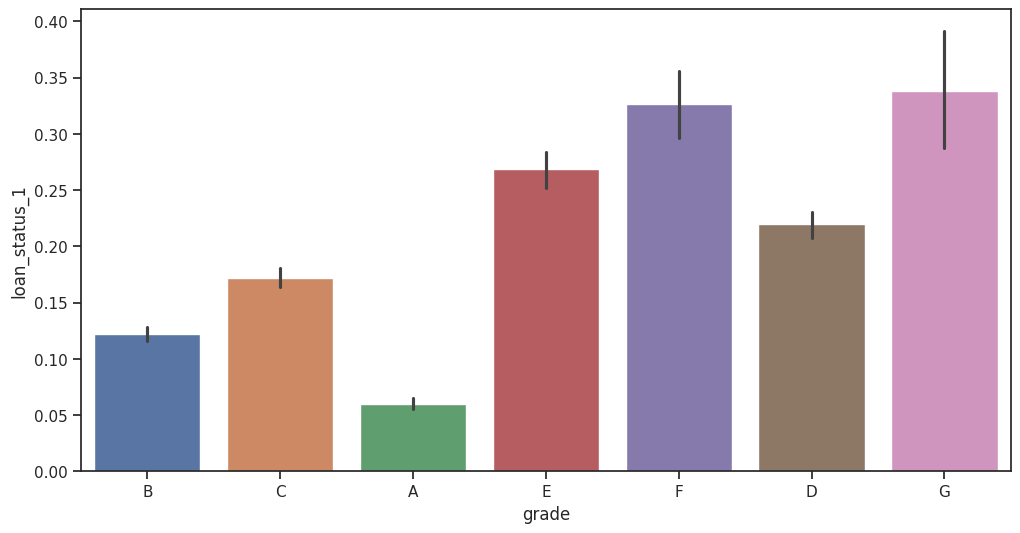

In [263]:
sns.set_theme(style="ticks")
plt.figure(figsize = (12,6))
sns.barplot(x='grade', y='loan_status_1', data = df,hue = 'grade')
plt.show()

This chart shows that what is the average % of defaulters in each grade. According to this chart the most defaulters are from grade G and F.

We should avoid giving high amount of loans to the borrowers of grade
F and G and we should give it for a high rate of interest as we can get more amount in return of the risk.

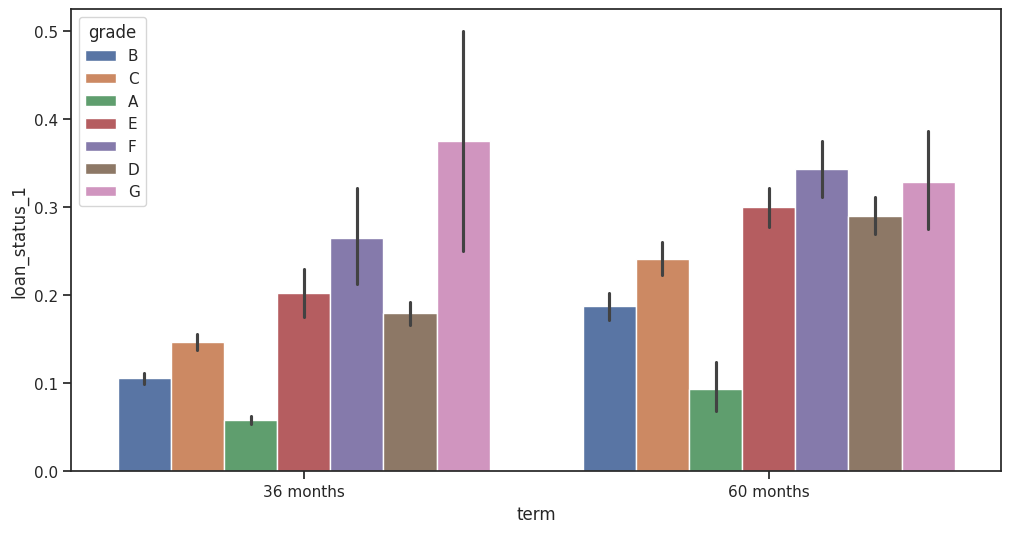

In [264]:
sns.set_theme(style="ticks")
plt.figure(figsize = (12,6))
sns.barplot(x = 'term', y = 'loan_status_1',data = df,hue = 'grade')
plt.show()

This shows the % of defaulters according to the term of loan they are taking.We should be careful while giving the loan to the people asking for loan for 60 months.

We can see that out of 100 people only 5 of the borrowers of the grade A become defaulters if the borrower ha taken a loan for 36 months and only 7 people become defaulters if the borrower has taken a loan for 60 months.

We can see that out of 100 people 30 of the borrowers of the grade G become defaulters if the borrower has taken a loan for 36 months and 28 people become defaulters if the borrower has taken a loan for 60 months.

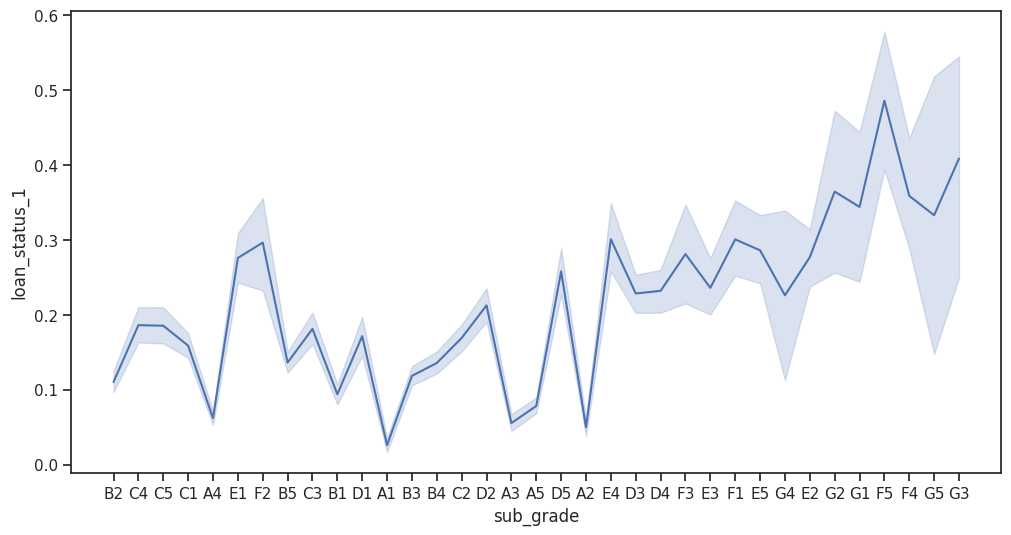

In [205]:
sns.set_theme(style="ticks")
plt.figure(figsize = (12,6))
sns.lineplot(x = 'sub_grade', y = 'loan_status_1',data = df)
plt.show()

The line chart shows the sub grades that have the possibilities of defaulting and as the Grades F and G are highest for defaulaters , the sub grades of F and G will also be highest.

We should limit the giving of loan to only some of the sub grades as the risk is much higher of defaulting as there is not much guarantee of return from the investment.

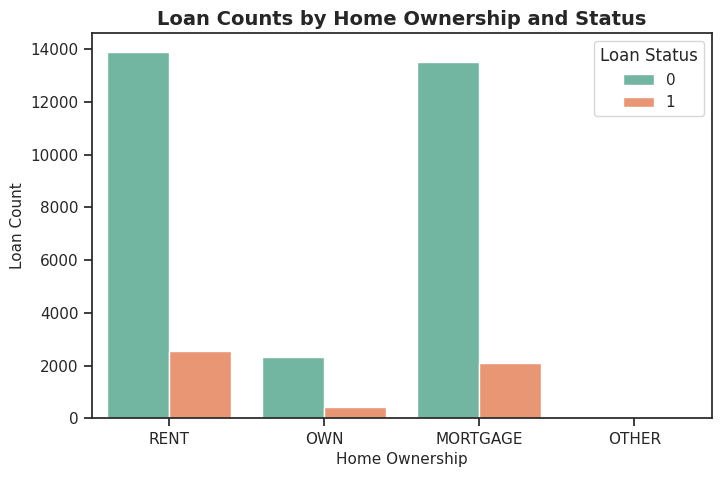

In [206]:
sns.set_theme(style="ticks")
plt.figure(figsize=(8, 5))

sns.countplot(data=df,x="home_ownership",hue="loan_status_1",palette="Set2")

plt.title("Loan Counts by Home Ownership and Status", fontsize=14, weight="bold")
plt.xlabel("Home Ownership", fontsize=11)
plt.ylabel("Loan Count", fontsize=11)
plt.legend(title="Loan Status", frameon=True)

plt.show()

This chart shoes that what is the percentage of defaulters according to the living condition of the loan borrower.The people who are living on rent has the highest rate of defaulters.

We should increase the amount of loans given against mortgages as they can be used as a guarantee and if there is defaulters then we can start an auction of the property to earn profit more than what we have invested.

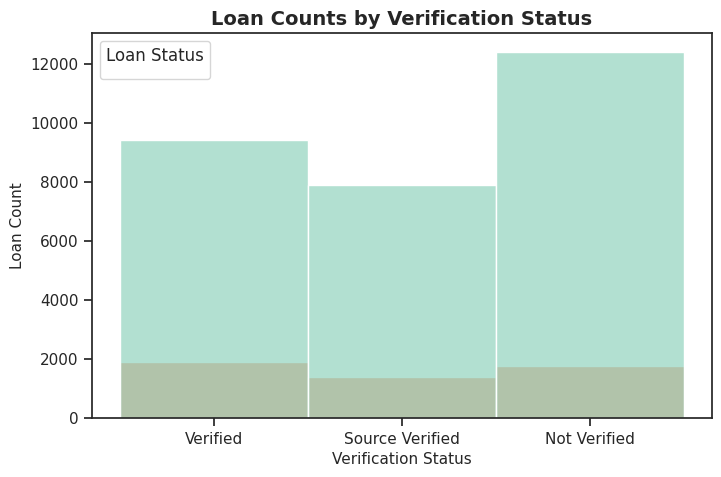

In [207]:
sns.set_theme(style="ticks")
plt.figure(figsize=(8, 5))

sns.histplot(data=df,x="verification_status",hue="loan_status_1",palette="Set2")

plt.title("Loan Counts by Verification Status", fontsize=14, weight="bold")
plt.xlabel("Verification Status", fontsize=11)
plt.ylabel("Loan Count", fontsize=11)
plt.legend(title="Loan Status", frameon=True, loc='upper left')

plt.show()

This chart shows that which type of people are gettig defaulters. Verified people are more defaulters and hence it is an advice to verify the loan takers with more precisally.

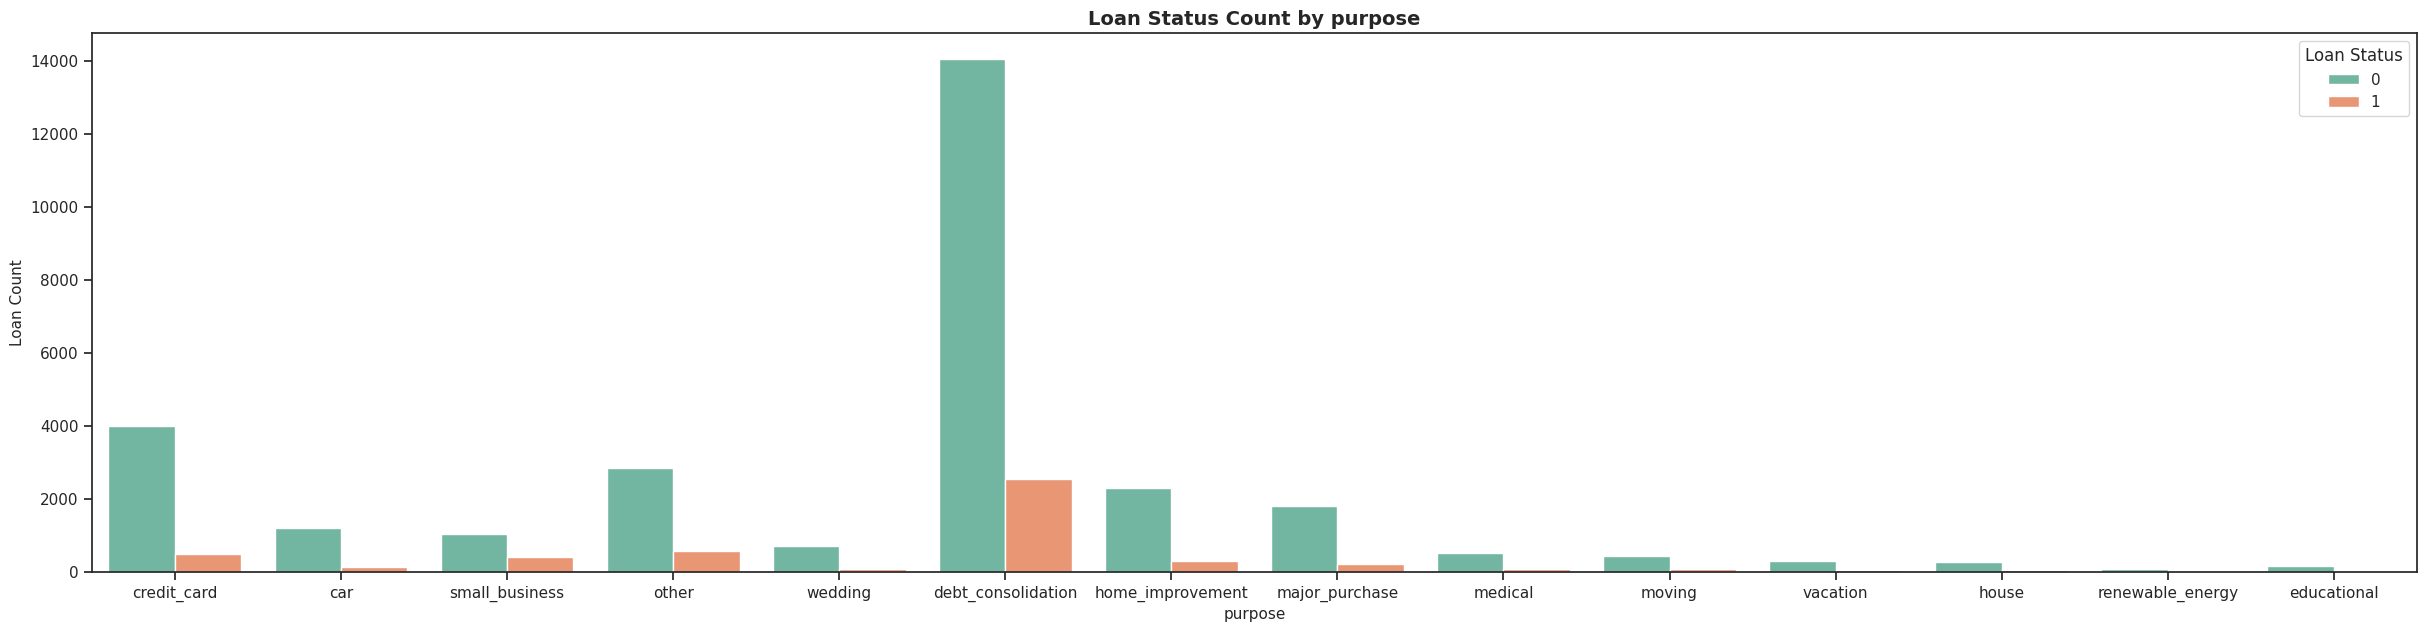

In [208]:
sns.set_theme(style="ticks")
plt.figure(figsize=(30,7))

sns.countplot(data=df,x="purpose",hue="loan_status_1",palette="Set2")

plt.title("Loan Status Count by purpose", fontsize=14, weight="bold")
plt.xlabel("purpose", fontsize=11)
plt.ylabel("Loan Count", fontsize=11)
plt.legend(title="Loan Status", frameon=True)

plt.show()

This chart shows that which purpose of loans get more defaulters.The small businesses become more defaulters as they have a high amount of risk of not surviving in the market and hence the declare themselves insolvents and hence we cannot recover the pending amount by law.

The highest defaulters are seen where the loan is taken to repay the existing amount of loan as the don't have the necessary liquidity to pay their existing debt and hence they get trap in a debt trap where they pays a loan by taking a new loan.

The lowest amount of defaulters are in renewable energy as they are mostly funded and backed by the government for the upliftment of the area and hence they do not worry about the debts.

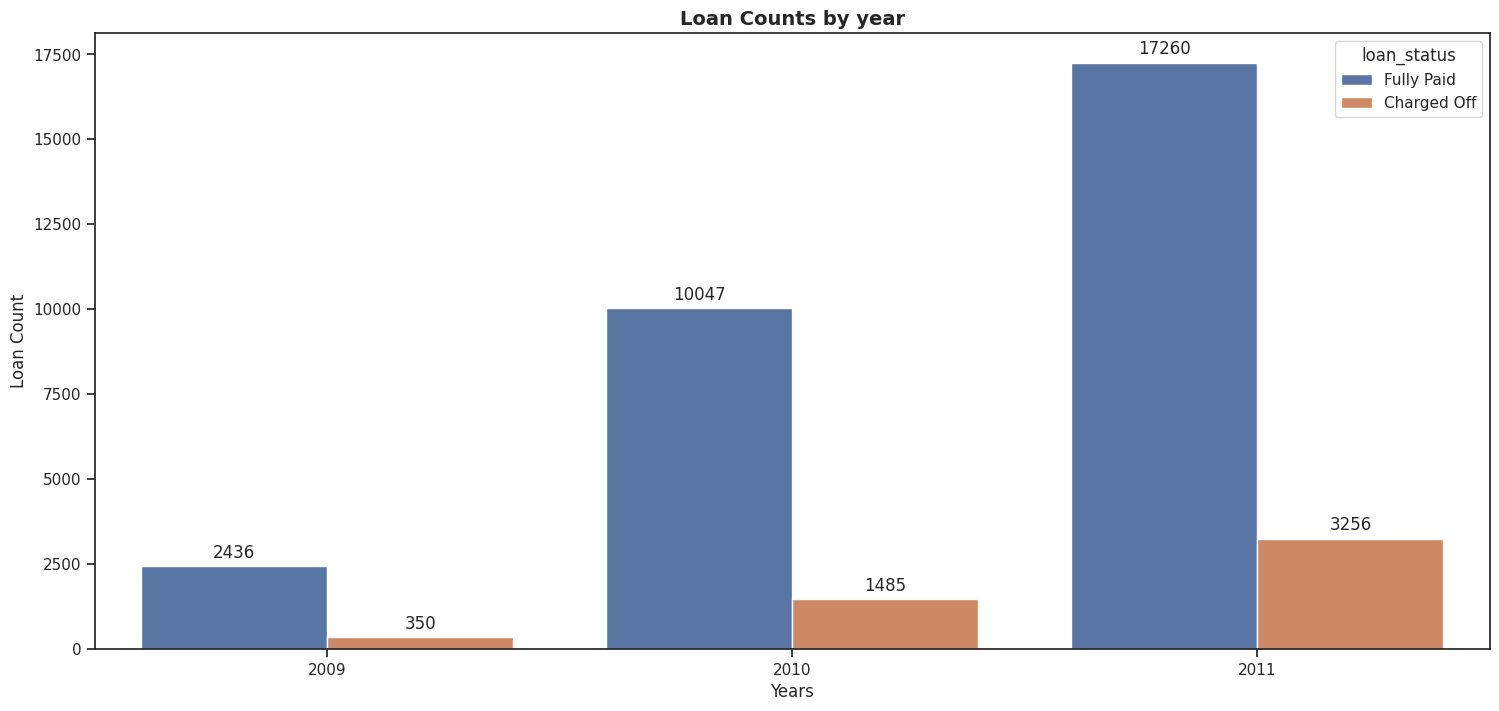

In [209]:
df['issue_d_1'] = pd.to_datetime(df['issue_d'] , format = '%b-%y', errors='coerce')
df['month'] = df['issue_d_1'].dt.month
df['year'] = df['issue_d_1'].dt.year
df.groupby('year').year.count()

sns.set_theme(style="ticks")
plt.figure(figsize=(18, 8))

ax = sns.countplot(x='year', hue='loan_status', data=df)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

ax.set_title("Loan Counts by year",weight="bold",fontsize = 14)
ax.set_xlabel("Years")
ax.set_ylabel("Loan Count")

plt.show()

Changing the format of issued date

This chart shows that in which year the most amount of defaulters has happened.The reason that can be is that the most amount of loan is given in 2011.

15.00% of the total loans given in 2011 were defaults because the more the number of loans given the wider the dataset and hence there are more chances of defaults.

12.00% of the total loans given in 2010 were defaults.

11.30% of the total loans given in 2009 were defaults.

15.60% of the total loans given in 2008 were defaults.

14.90% of the total loans given in 2007 were defaults.

In [210]:
#It counts the total number of loans given in each month of all the years combined
df.groupby('month').month.count()

,month
month,
1,1969
2,1924
3,2179
4,2386
5,2529
6,2757
7,3048
8,3284
9,3448


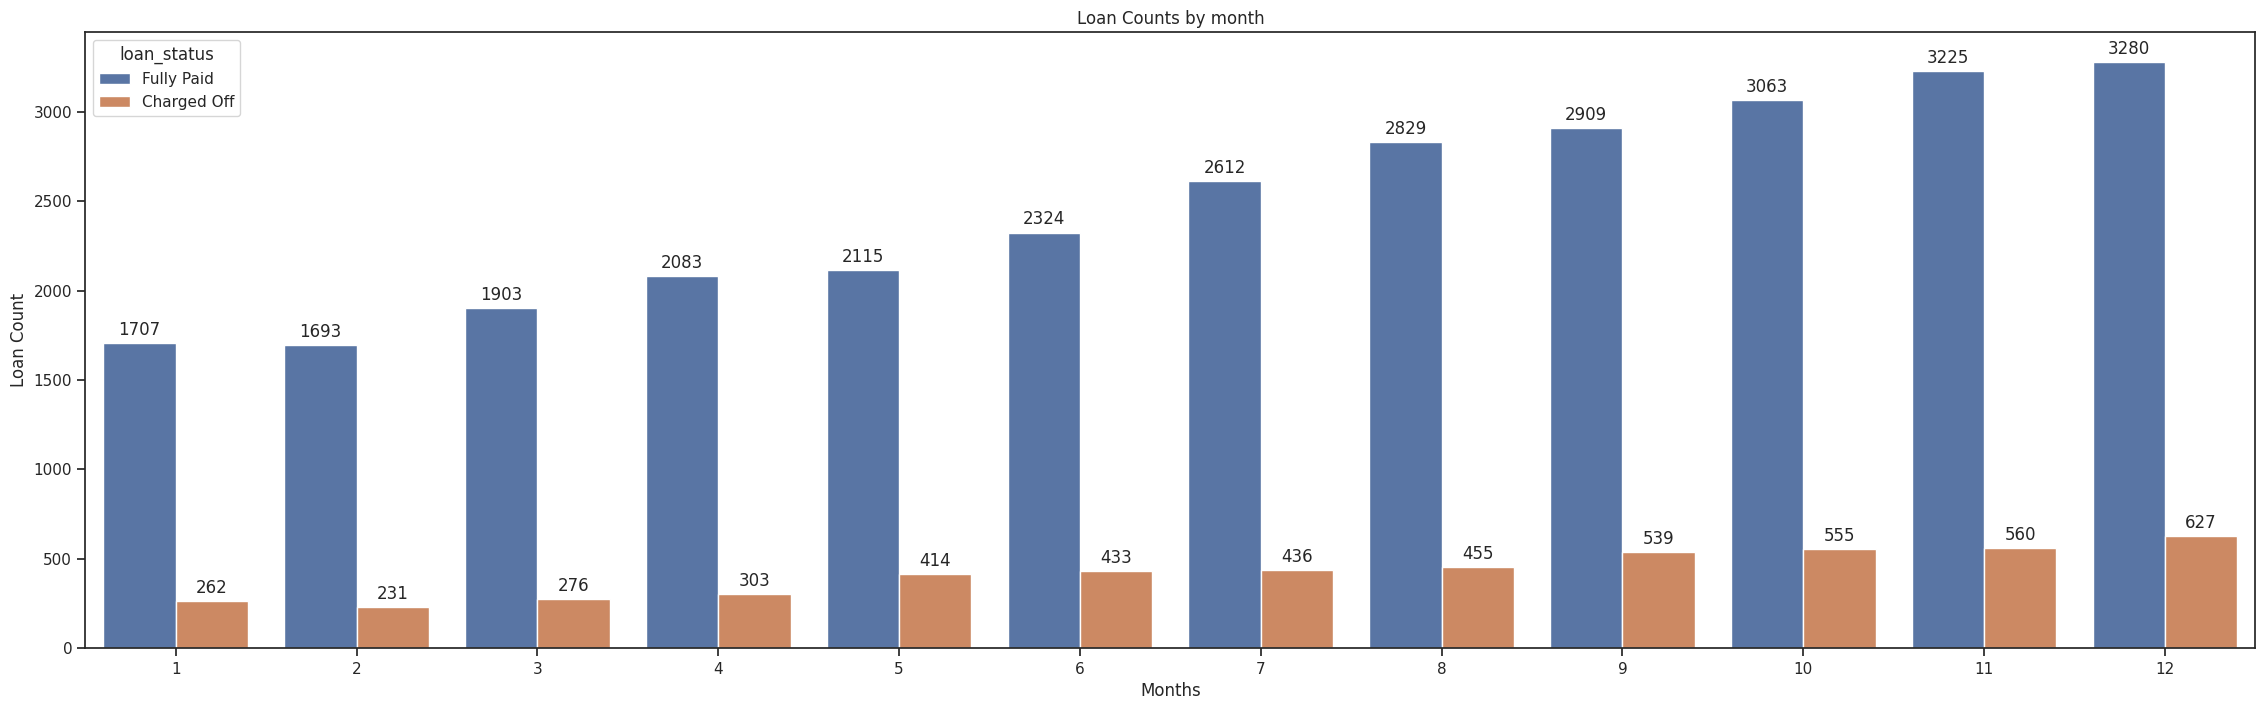

In [211]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 8))

ax = sns.countplot(x='month', hue='loan_status', data=df)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

ax.set_title("Loan Counts by month")
ax.set_xlabel("Months")
ax.set_ylabel("Loan Count")

plt.show()

This shows that in which month the most amount of defaulters has happened and the data is of all the years combined.

The most amount of loans are given on the months of november and december as these are the months where people goes for a vacation and spend their earnings.

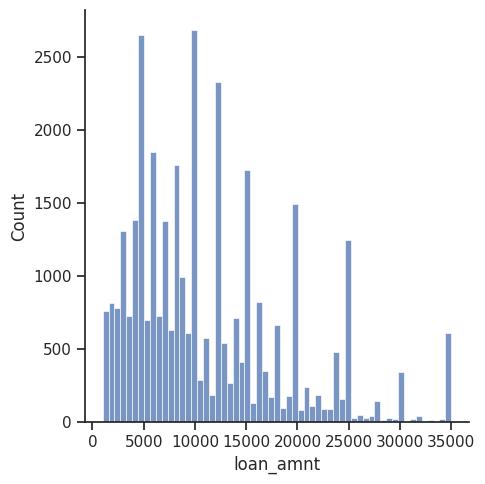

In [212]:
sns.displot(df['loan_amnt'])
plt.show()

This chart shows that what is the amount of loan given to number of people.

In [267]:
def loan_amount(n):
    if n < 5000:
        return 'low'
    elif n < 15000:
        return 'medium'
    elif n < 25000:
        return 'high'
    else:
        return 'very high'

df['loan_amnt_1'] = loan['loan_amnt'].apply(loan_amount)

In [268]:
df['loan_amnt_1'].value_counts()

,count
loan_amnt_1,
medium,20675
high,7696
low,7444
very high,2762


It categorizes the amount of loan given.

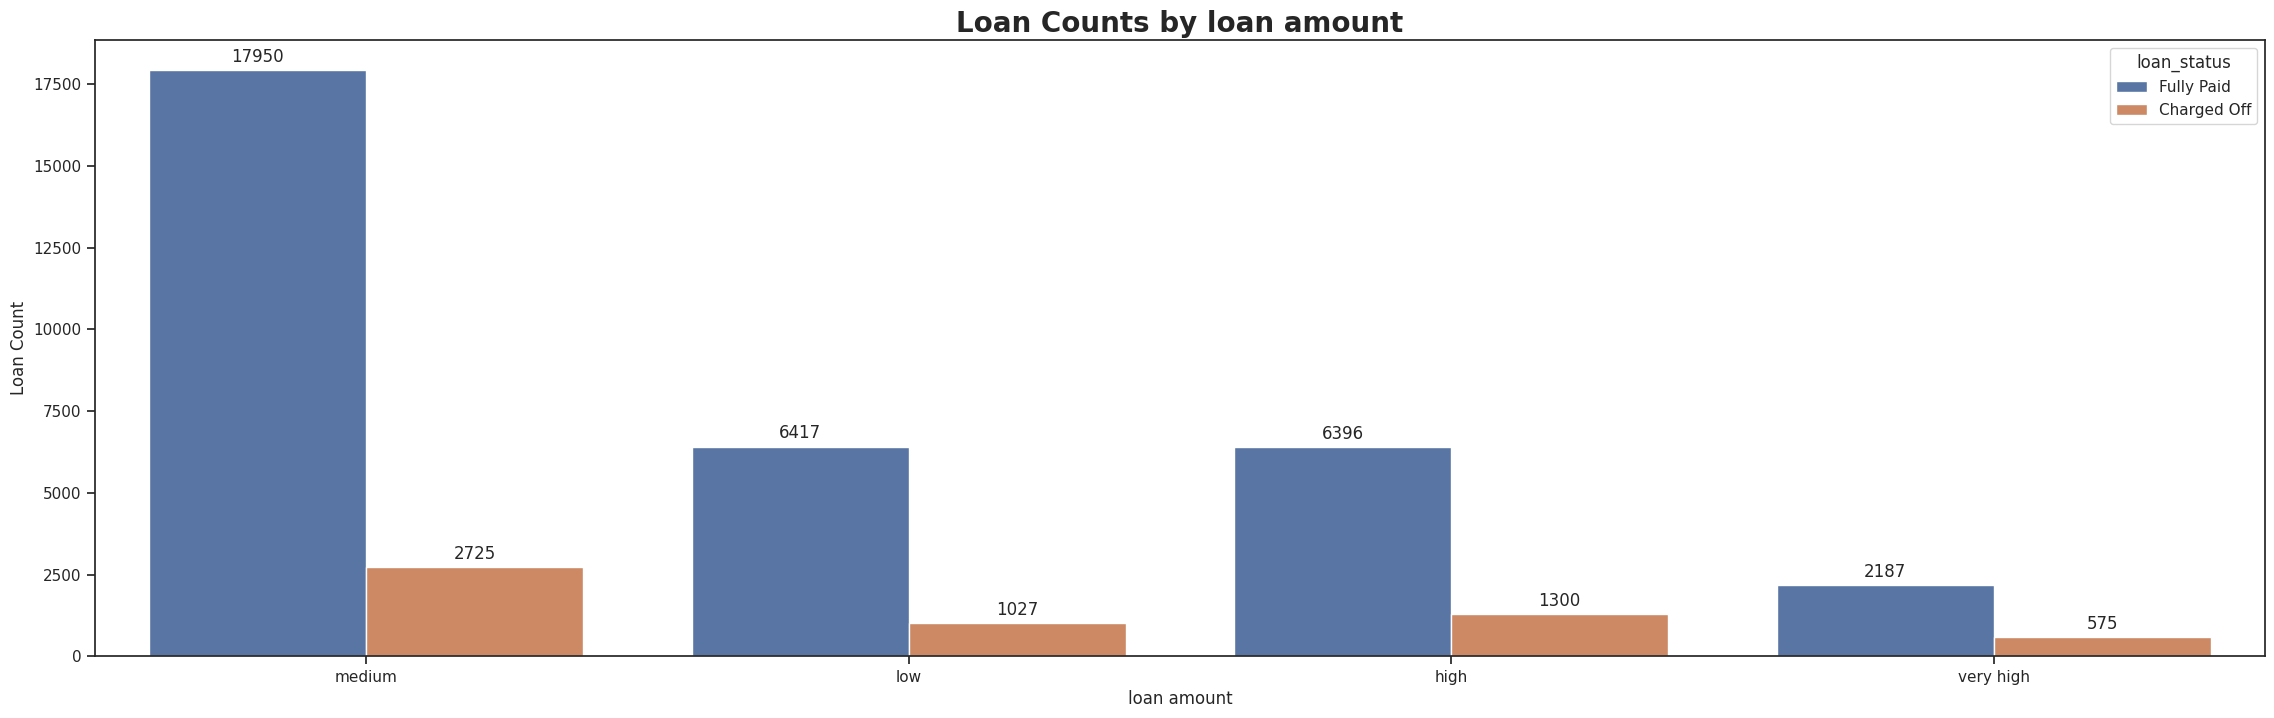

In [270]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 8))

ax = sns.countplot(x='loan_amnt_1', hue='loan_status', data=df)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

ax.set_title("Loan Counts by loan amount",fontsize = 20,weight = 'bold')
ax.set_xlabel("loan amount")
ax.set_ylabel("Loan Count")

plt.show()

This chart shows the categorization of the loan amount.We can see that if we provide very high amount of loan then there is a high chance of defaulters.

20% of the total loan amount given from the very high category is default which is the highest from all the above categories.

In [272]:
df['funded_amnt_inv_1'] = loan['funded_amnt_inv'].apply(loan_amount)

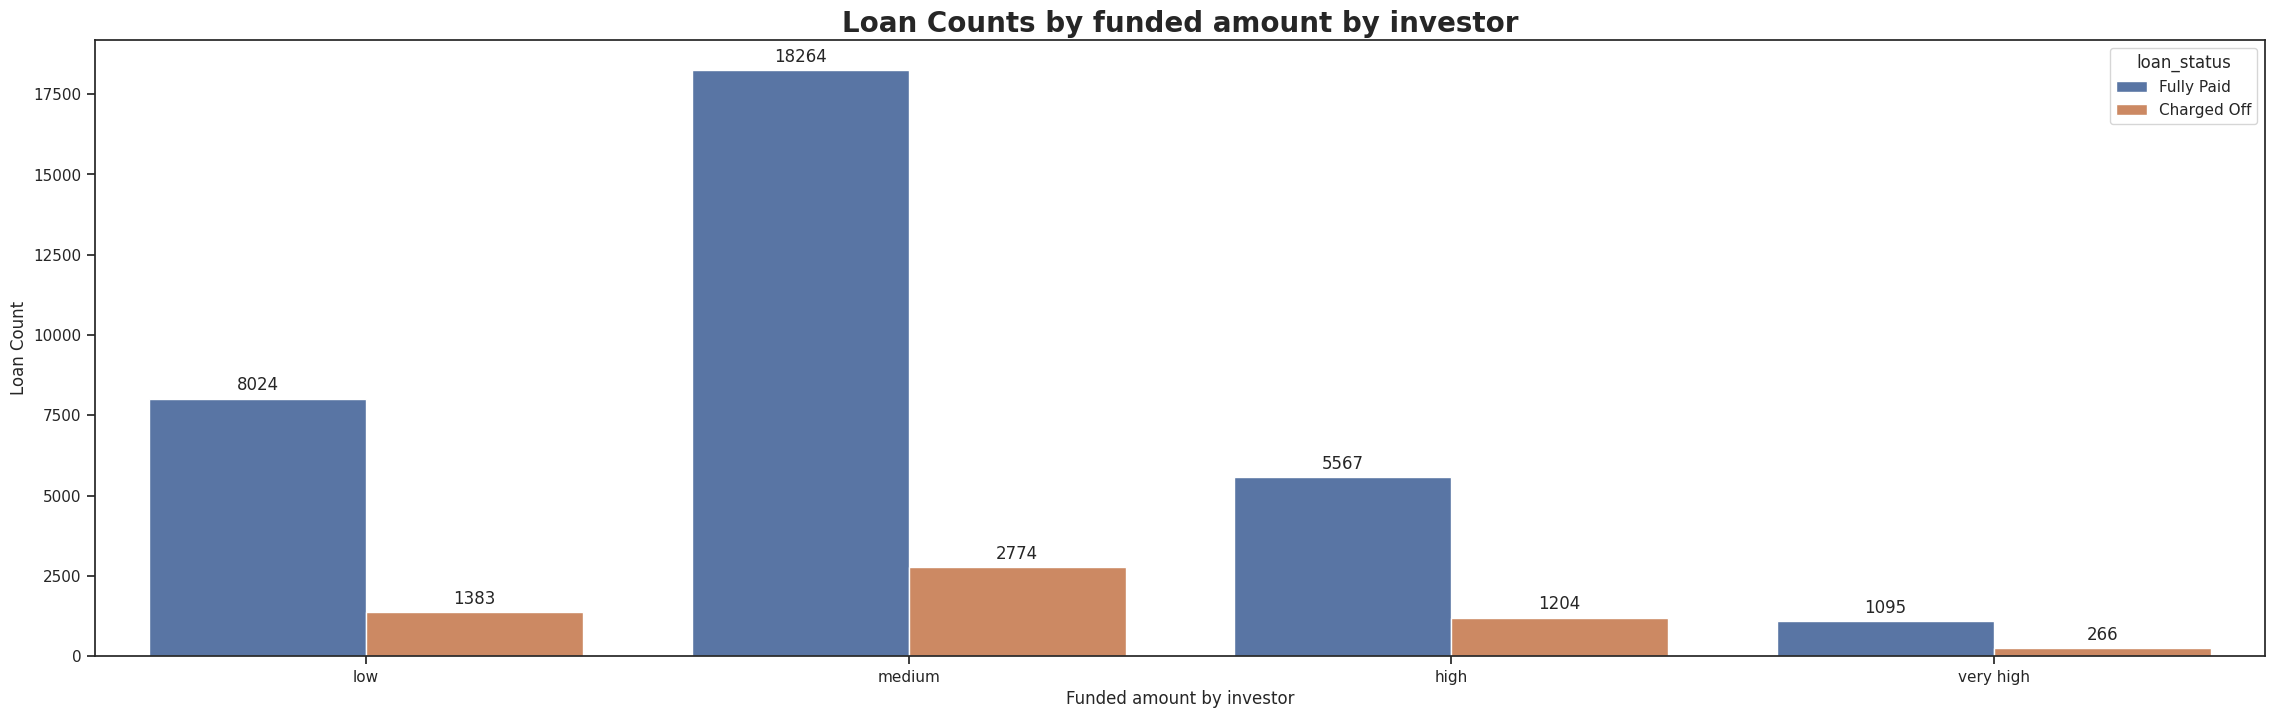

In [274]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 8))

ax = sns.countplot(x='funded_amnt_inv_1', hue='loan_status', data=df)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

ax.set_title("Loan Counts by funded amount by investor",fontsize = 20,weight = 'bold')
ax.set_xlabel("Funded amount by investor")
ax.set_ylabel("Loan Count")

plt.show()

This chart shows the amount of defaulters and non defaulters according to the invested amount by the investor.

As the amount invested by the investor is medium, the percentage of defaulters is also the least out of all.

In [275]:
def int_rate_1(n):
  if n<=10:
    return('low')
  elif n > 10 and n <=15:
    return('medium')
  else:
    return('high')

df['int_rate_2'] = df['int_rate_1'].apply(int_rate_1)

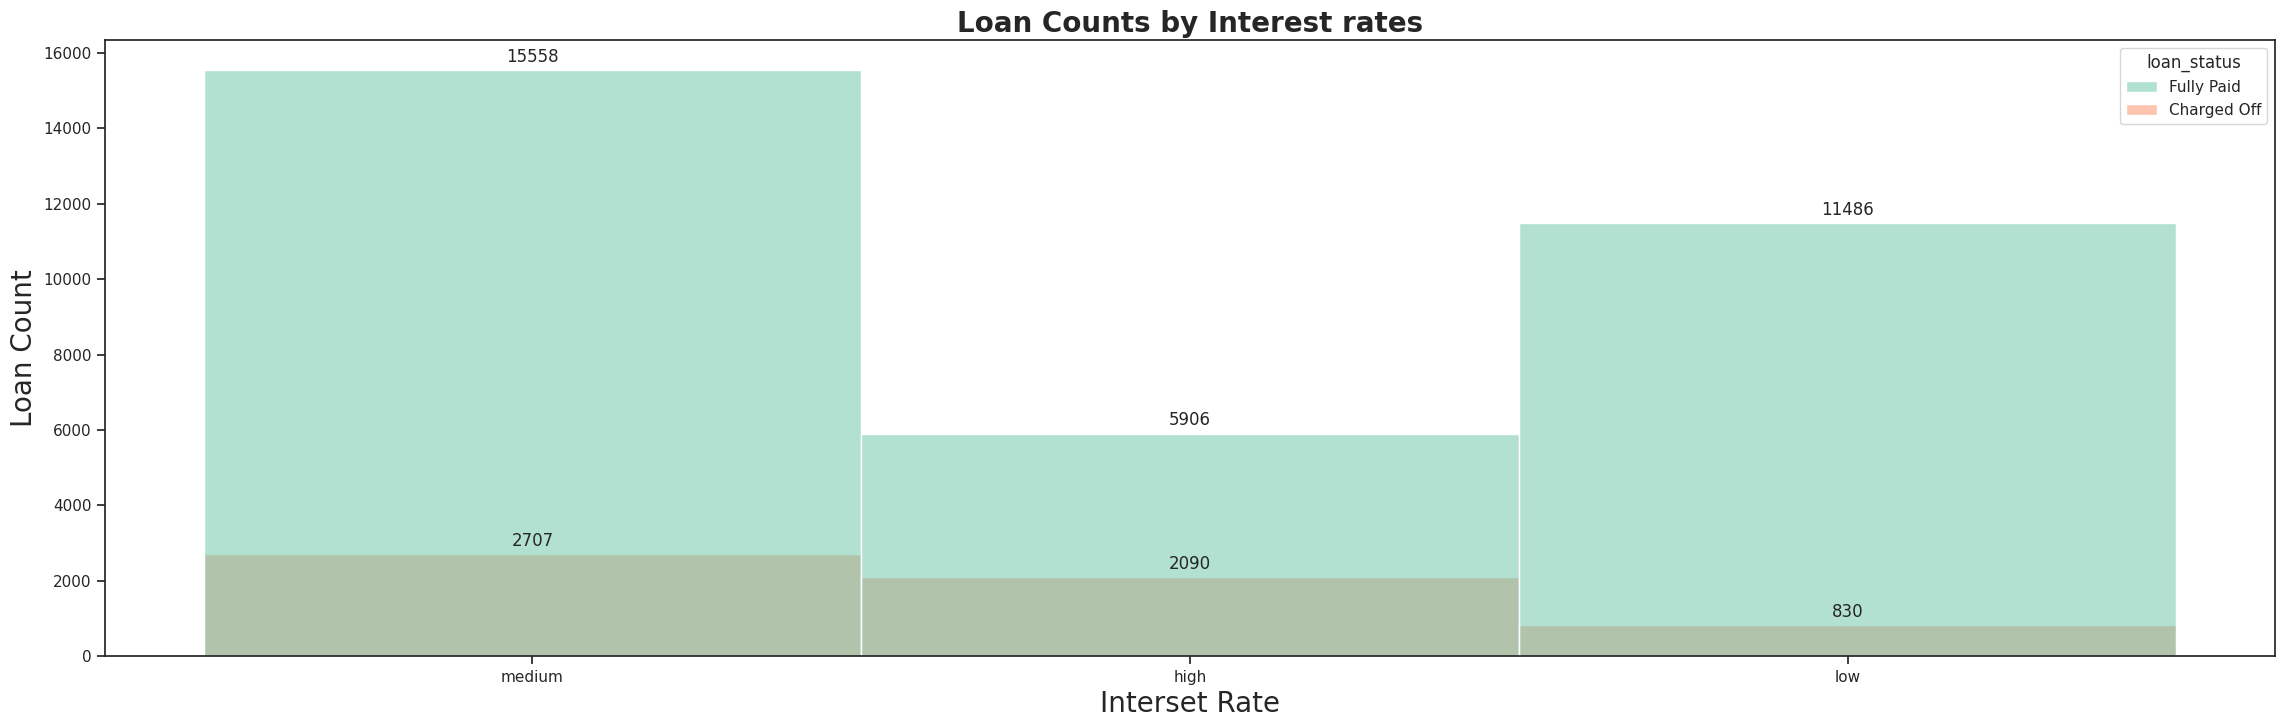

In [277]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 8))

ax = sns.histplot(x='int_rate_2', hue='loan_status', data=df,palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

ax.set_title("Loan Counts by Interest rates",fontsize = 20,weight = 'bold')
ax.set_xlabel("Interset Rate",fontsize = 20)
ax.set_ylabel("Loan Count",fontsize = 20)

plt.show()

This chart shows the amount of defaulters and non defaulters according to the interest rates.

As we have given the most amount of loans on average rate of interest, the % of defaulters is also less compared to the others.

In [279]:
def dti(n):
  if n <= 10:
    return('low')
  elif n > 10 and n <= 20:
    return('medium')
  else:
    return('high')

df['dti_1'] = df['dti'].apply(dti)

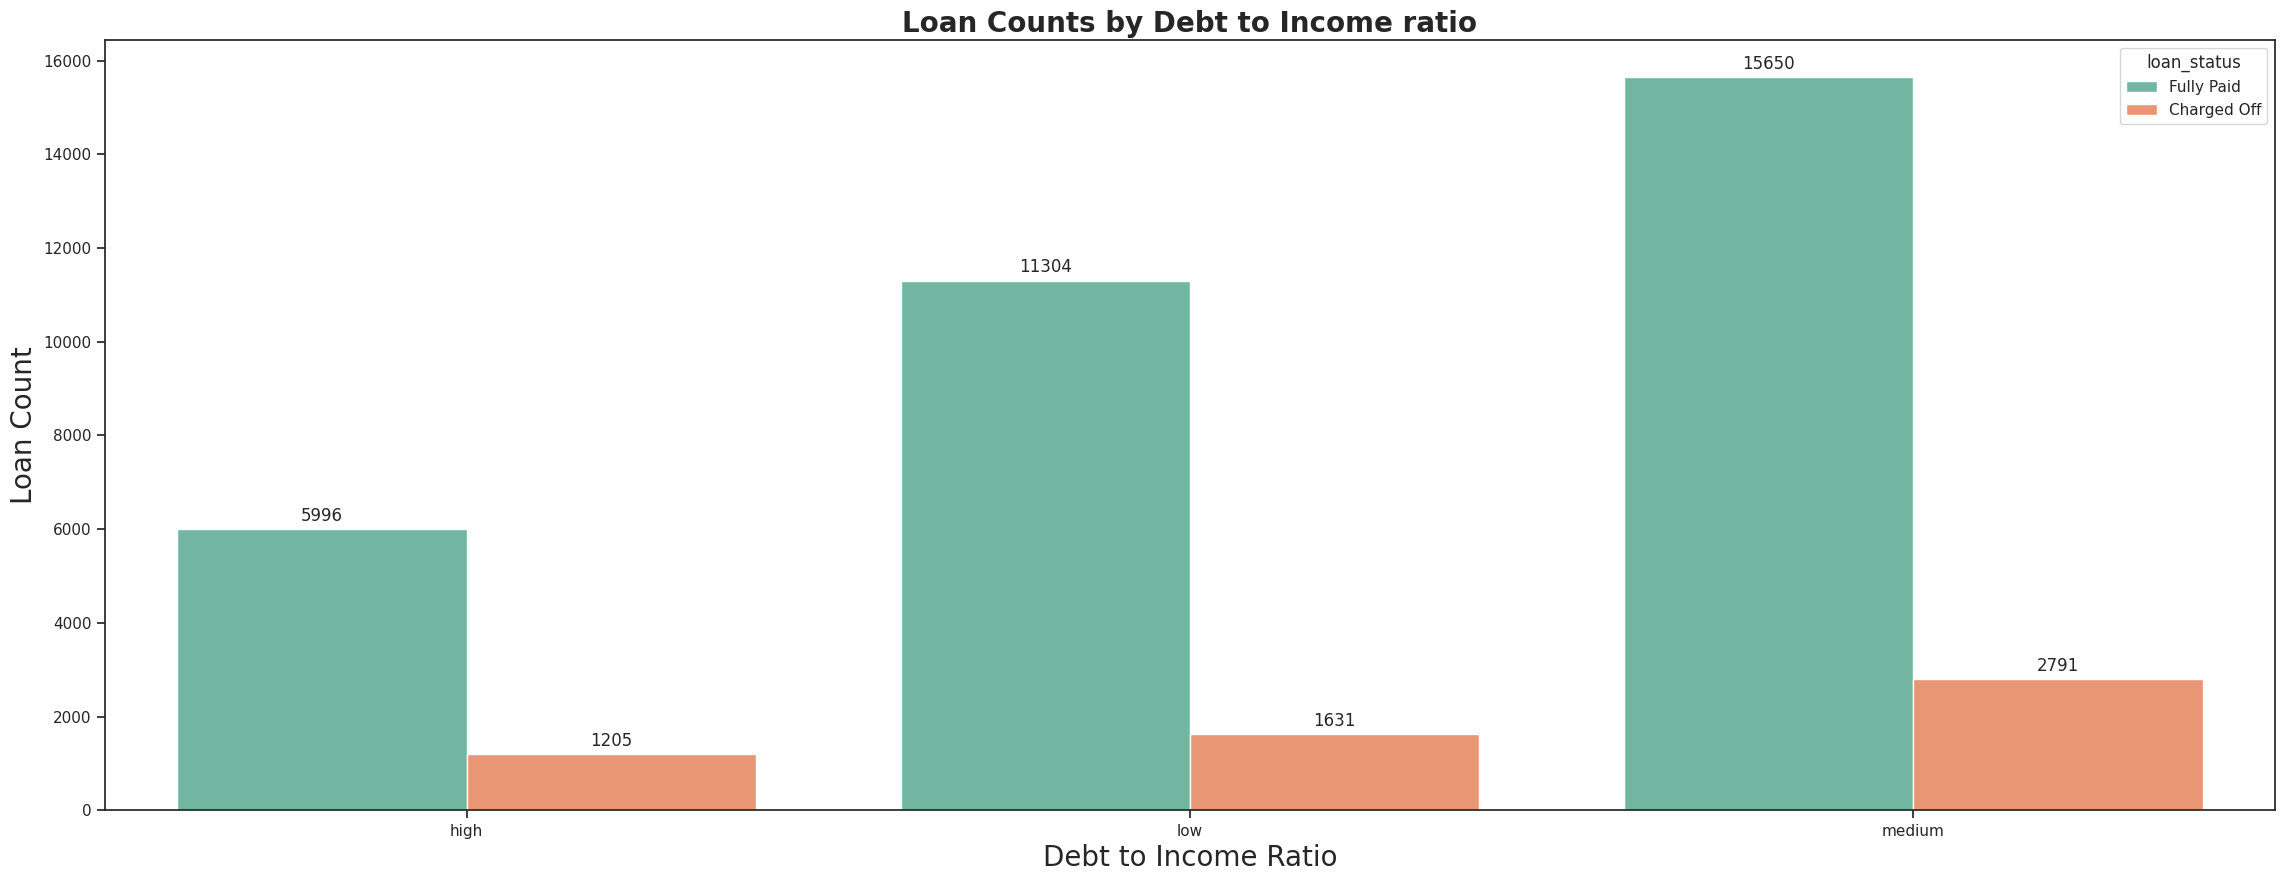

In [280]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 10))

ax = sns.countplot(x='dti_1', hue='loan_status', data=df,palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


ax.set_title("Loan Counts by Debt to Income ratio",fontsize = 20,weight = 'bold')
ax.set_xlabel("Debt to Income Ratio",fontsize = 20)
ax.set_ylabel("Loan Count",fontsize = 20)

plt.show()

 The debt-to-income (DTI) ratio measures how much of your monthly income is used to pay debts. It is calculated by dividing your total monthly debt payments by your gross monthly income (income before taxes and deductions) and expressing the result as a percentage.

 The people who have low DTI ratio has the least % of defaulters compared to others.

 The people who have average DTI ratio has the 2nd lowest % of defaulters.

  The people who have highest DTI ratio has the highest % of defaulters compared to others.

In [281]:
def funded_amount(n):
  if n <= 5000:
    return('low')
  elif n > 5000 and n <= 15000:
    return('medium')
  else:
    return('high')

df['funded_amnt_1'] = df['funded_amnt'].apply(funded_amount)

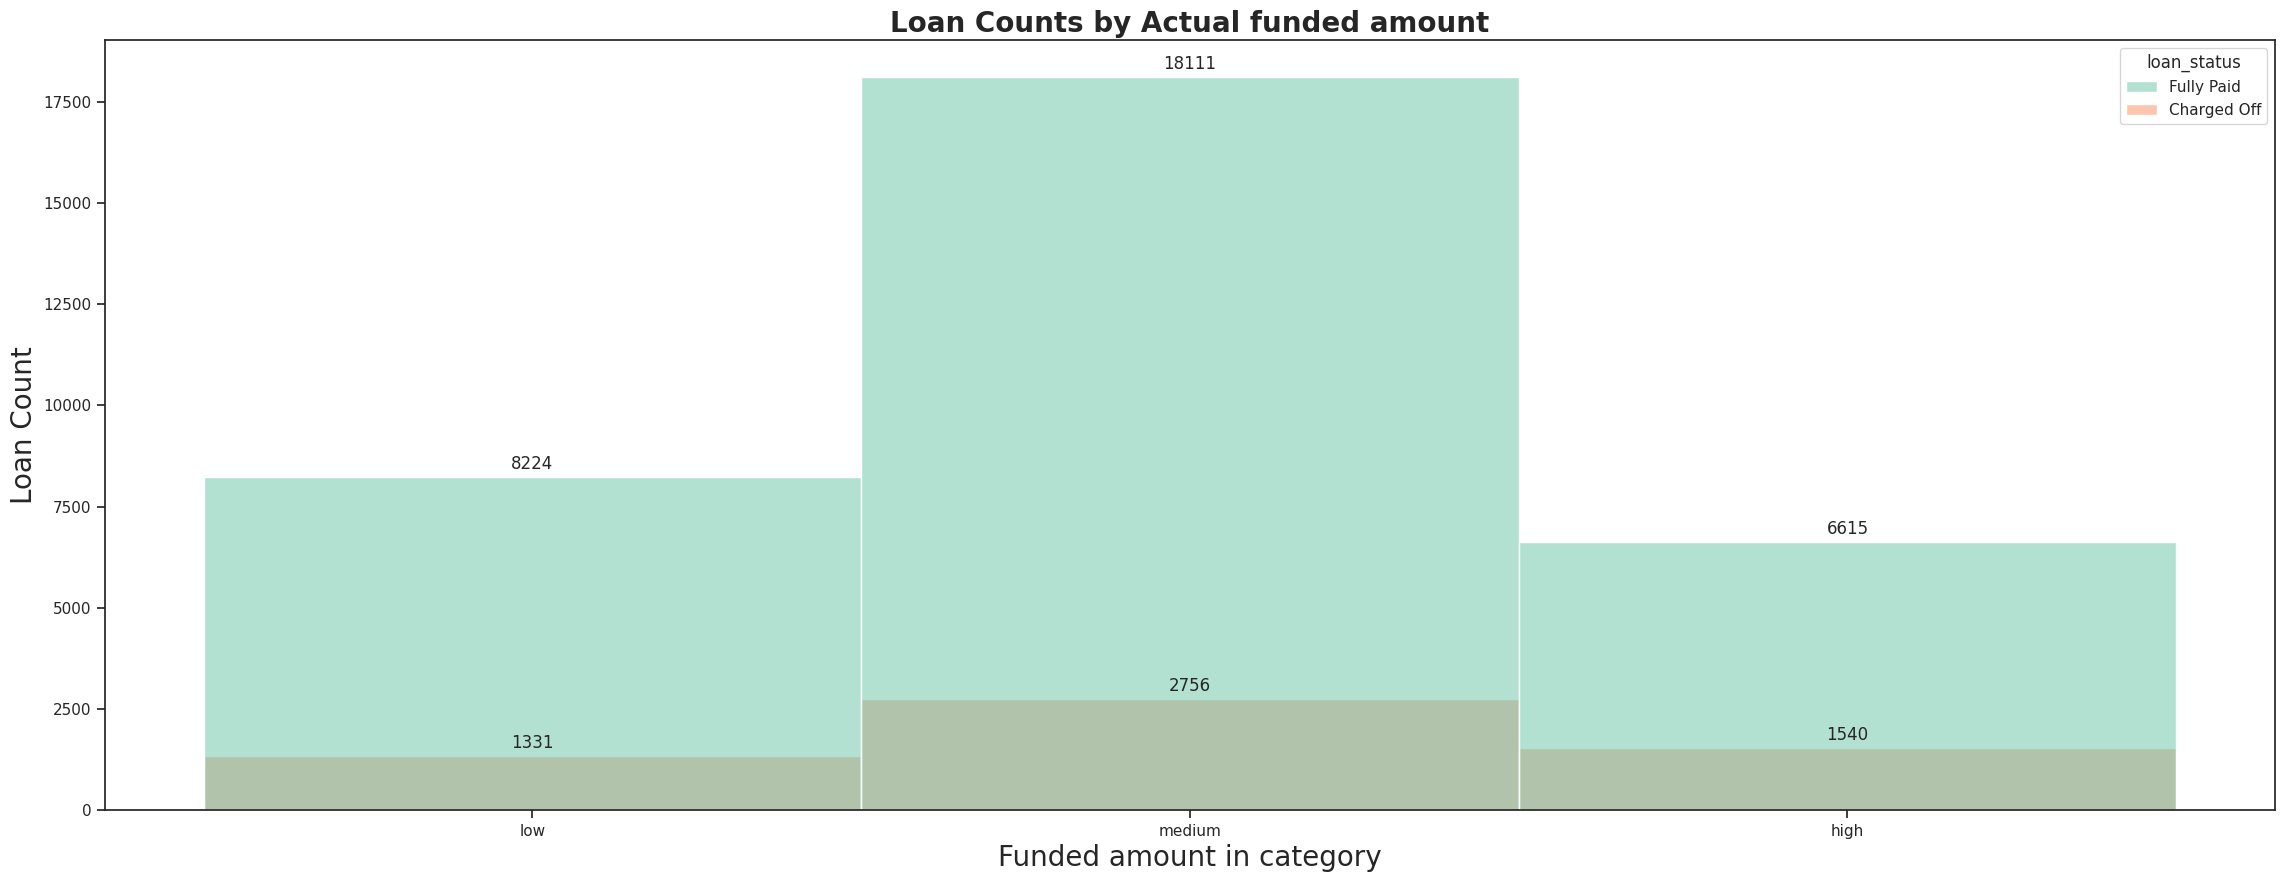

In [282]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 10))

ax = sns.histplot(x='funded_amnt_1', hue='loan_status', data=df,palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


ax.set_title("Loan Counts by Actual funded amount",fontsize = 20,weight = 'bold')
ax.set_xlabel("Funded amount in category" ,fontsize = 20)
ax.set_ylabel("Loan Count",fontsize = 20)

plt.show()

This chart shows the actual amount invested by the investor in categories.

As the loan providers provided the loan of an medium amount that is not very less or very high , the % of defaulters is the least compared to the loans given for a high or a less amount.

In [283]:
def installment(n):
  if n <= 200:
    return('low')
  elif n > 200 and n <= 400:
    return('medium')
  elif n > 400 and n <= 600:
    return('high')
  else:
    return('Very high')

df['installment_1'] = df['installment'].apply(installment)

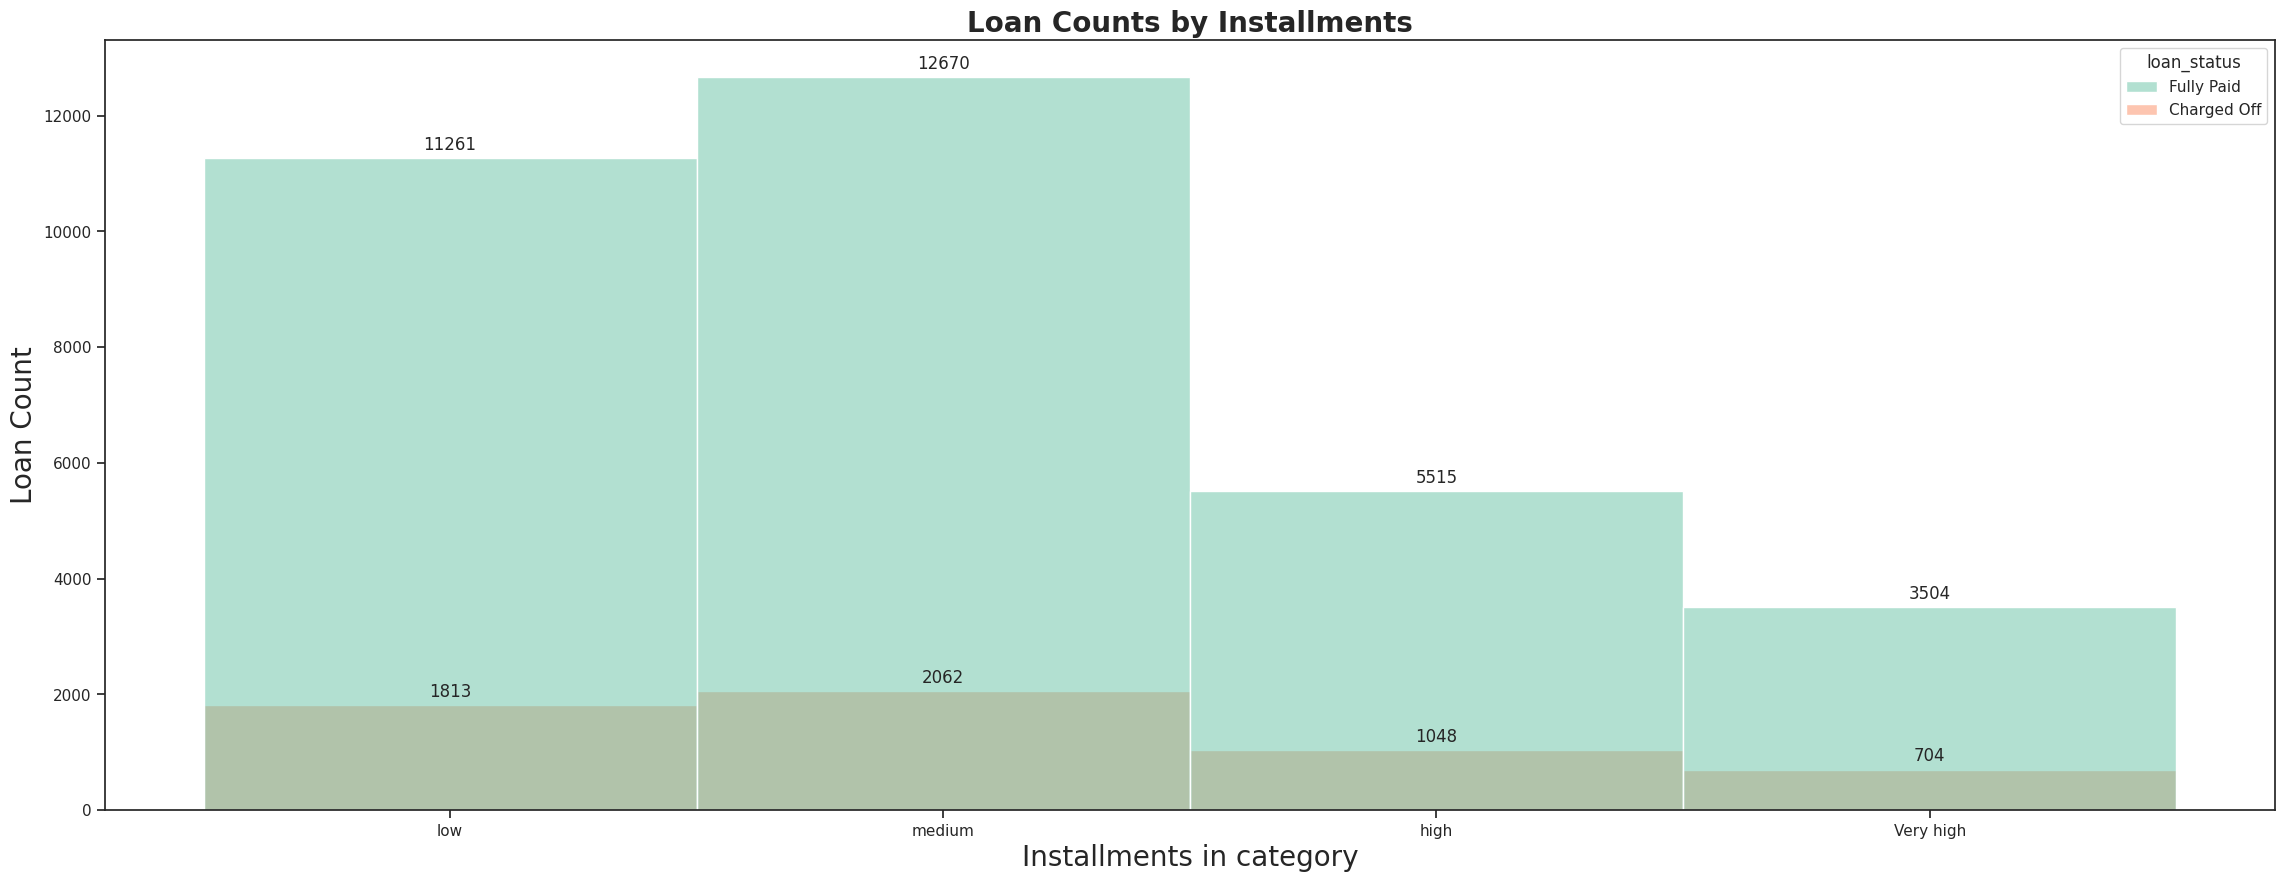

In [284]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 10))

ax = sns.histplot(x='installment_1', hue='loan_status', data=df,palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


ax.set_title("Loan Counts by Installments",fontsize = 20,weight = 'bold')
ax.set_xlabel("Installments in category" ,fontsize = 20)
ax.set_ylabel("Loan Count",fontsize = 20)

plt.show()

In [226]:
def annual_income(n):
  if n <= 50000:
    return('low')
  elif n > 50000 and n <= 100000:
    return('medium')
  elif n > 100000 and n <= 150000:
    return('high')
  else:
    return('Very high')

df['annual_income_1'] = df['annual_inc'].apply(annual_income)

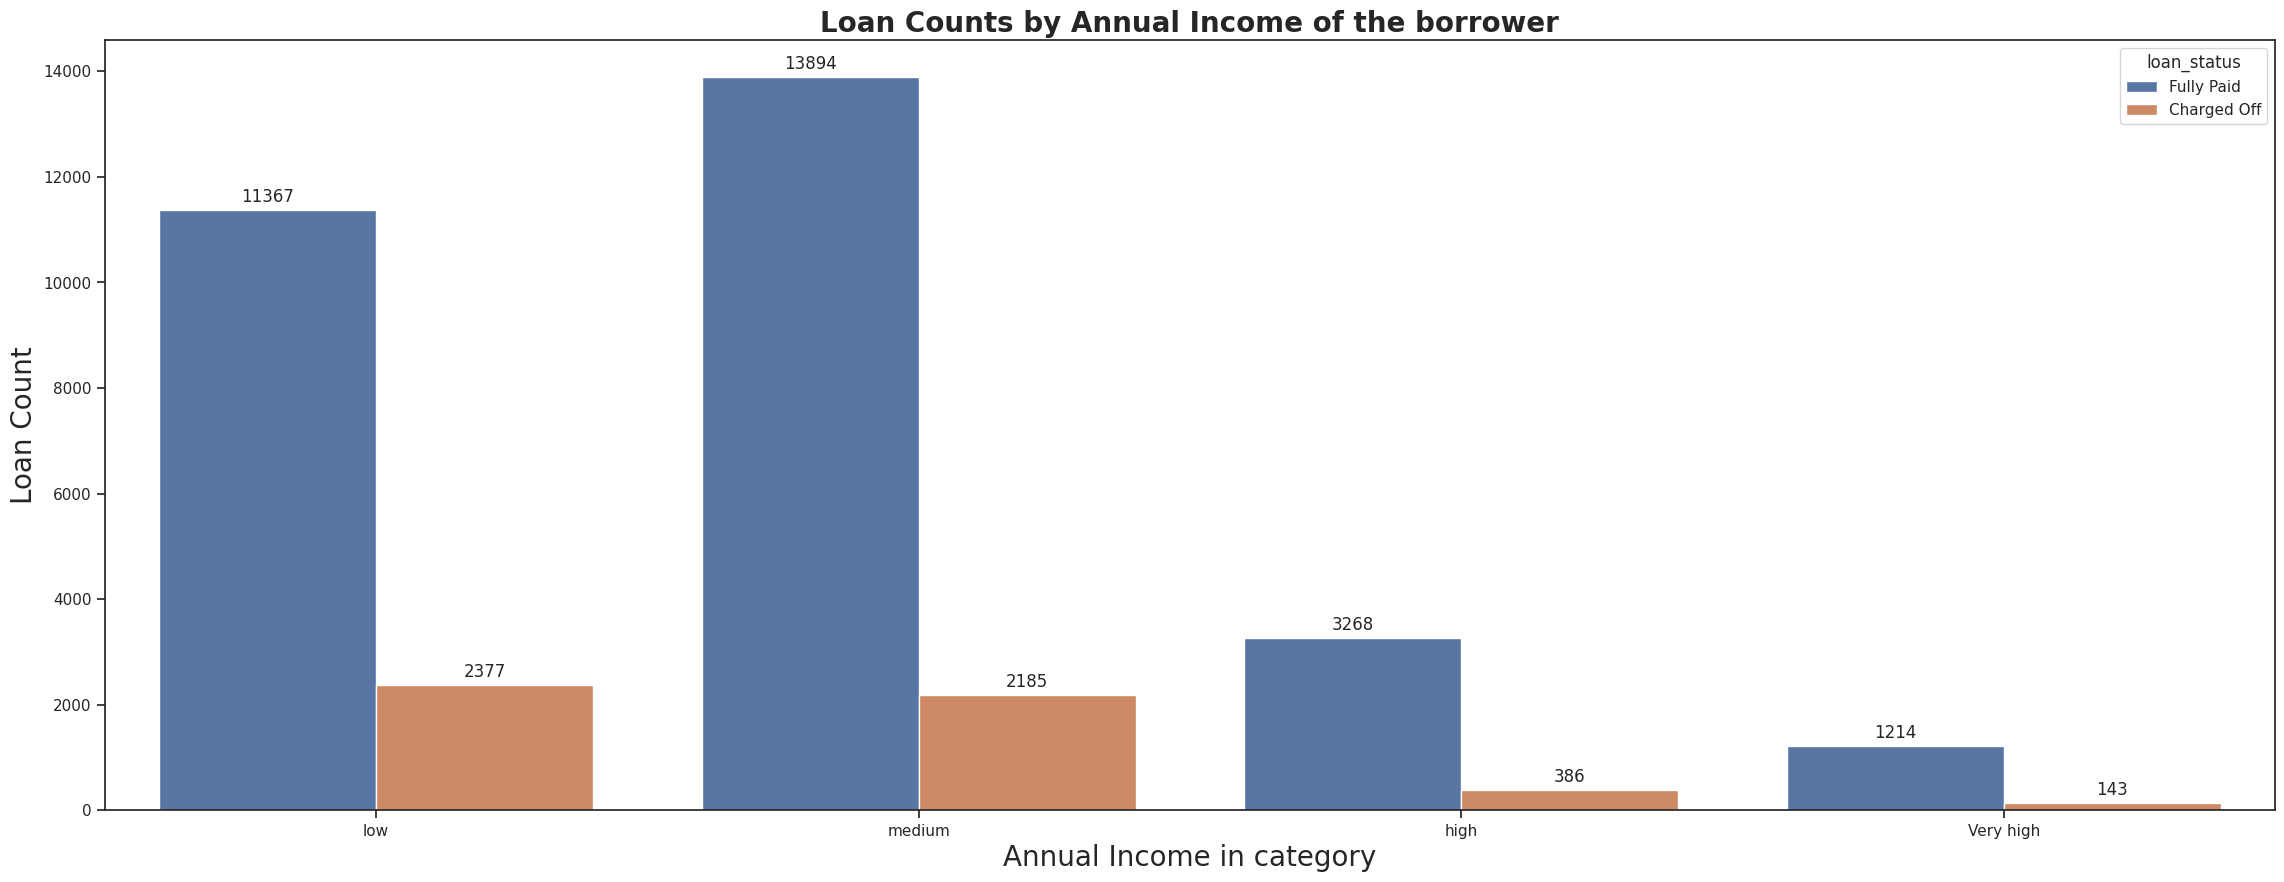

In [227]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 10))

ax = sns.countplot(x='annual_income_1',hue='loan_status', data=df)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


ax.set_title("Loan Counts by Annual Income of the borrower",fontsize = 20,weight = 'bold')
ax.set_xlabel("Annual Income in category" ,fontsize = 20)
ax.set_ylabel("Loan Count",fontsize = 20)

plt.show()

In [228]:
df = df[~df['emp_length_1'].isnull()]

In [229]:
def emp_length(n):
  n = int(n)
  if n <= 1:
    return('freshers')
  elif n > 1 and n <= 3:
    return('juniors')
  elif n > 3 and n <= 7:
    return('seniors')
  else:
    return('expert')

df['emp_length_2'] = df['emp_length_1'].apply(emp_length)

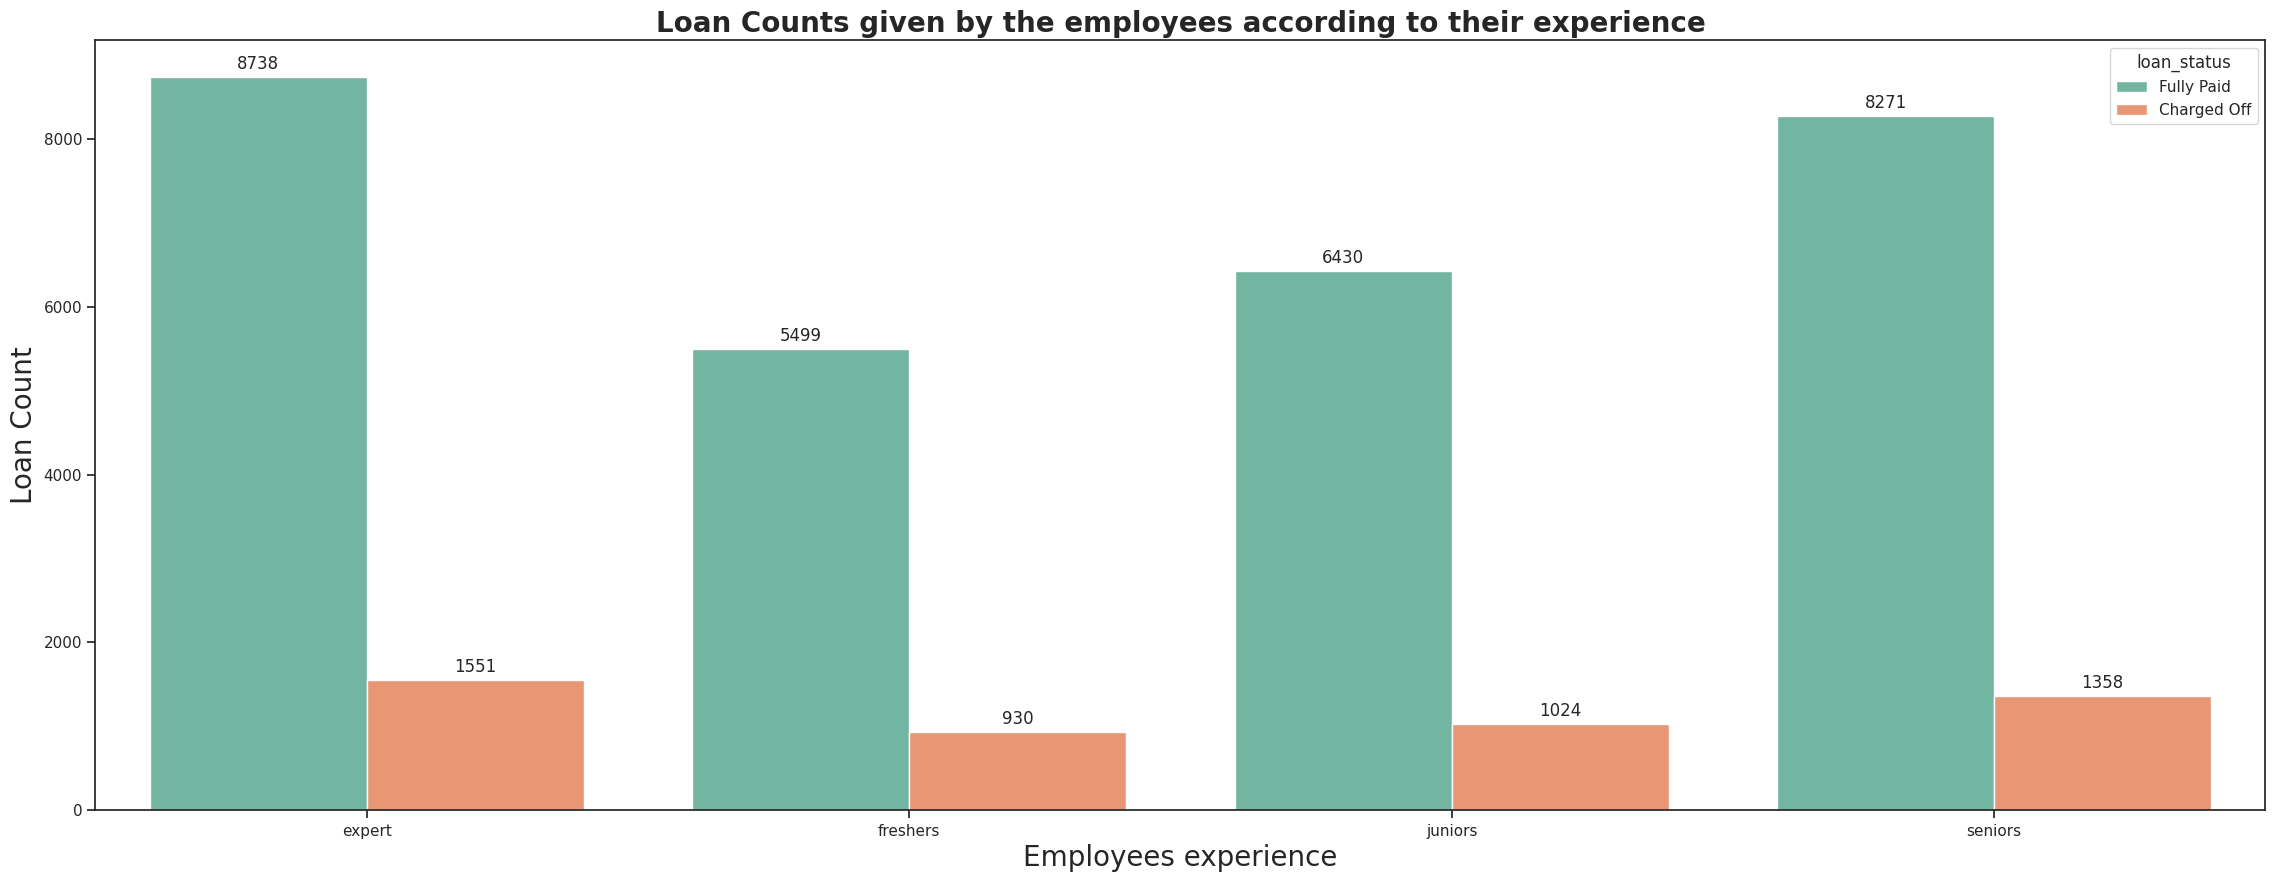

In [230]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 10))

ax = sns.countplot(x='emp_length_2',hue='loan_status', data=df,palette = 'Set2')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


ax.set_title("Loan Counts given by the employees according to their experience",fontsize = 20,weight = 'bold')
ax.set_xlabel("Employees experience" ,fontsize = 20)
ax.set_ylabel("Loan Count",fontsize = 20)

plt.show()

# ***Segmented Univariate Analysis***

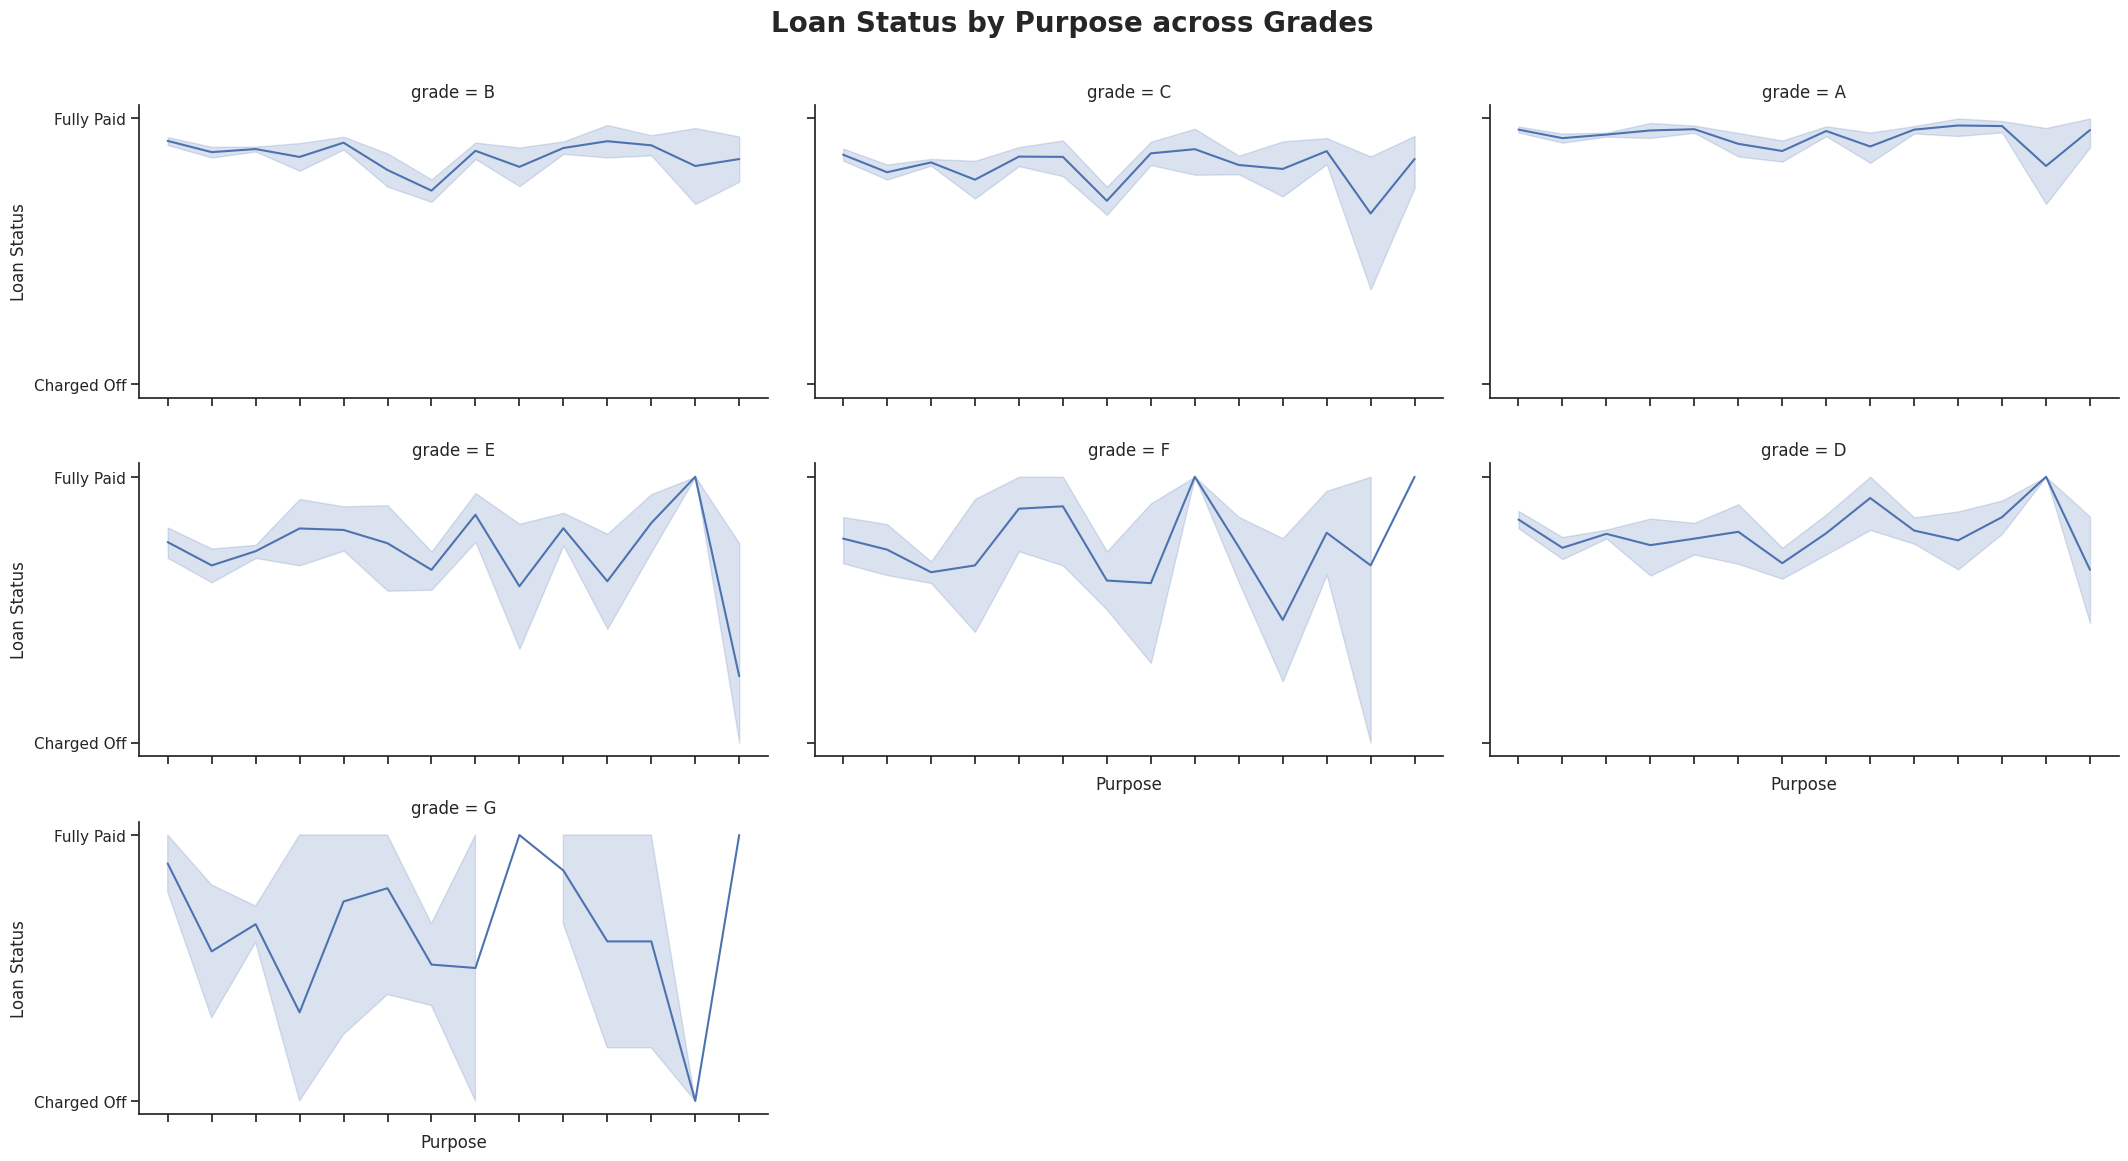

In [231]:
sns.set_theme(style="ticks")

g = sns.relplot(data=df,x="purpose",y="loan_status",col="grade",col_wrap=3,kind="line",height=4,aspect=1.8,)

g.set_xticklabels(rotation=45, ha="right")

g.set_axis_labels("Purpose", "Loan Status", fontsize=12)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Loan Status by Purpose across Grades", fontsize=20,weight = 'bold')

plt.show()

In [232]:
main_purpose = ['credit_card','debt_consolidation','home_improvement','major_purchase']
df = df[df['purpose'].isin(main_purpose)]
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,16227
credit_card,4354
home_improvement,2516
major_purchase,1940


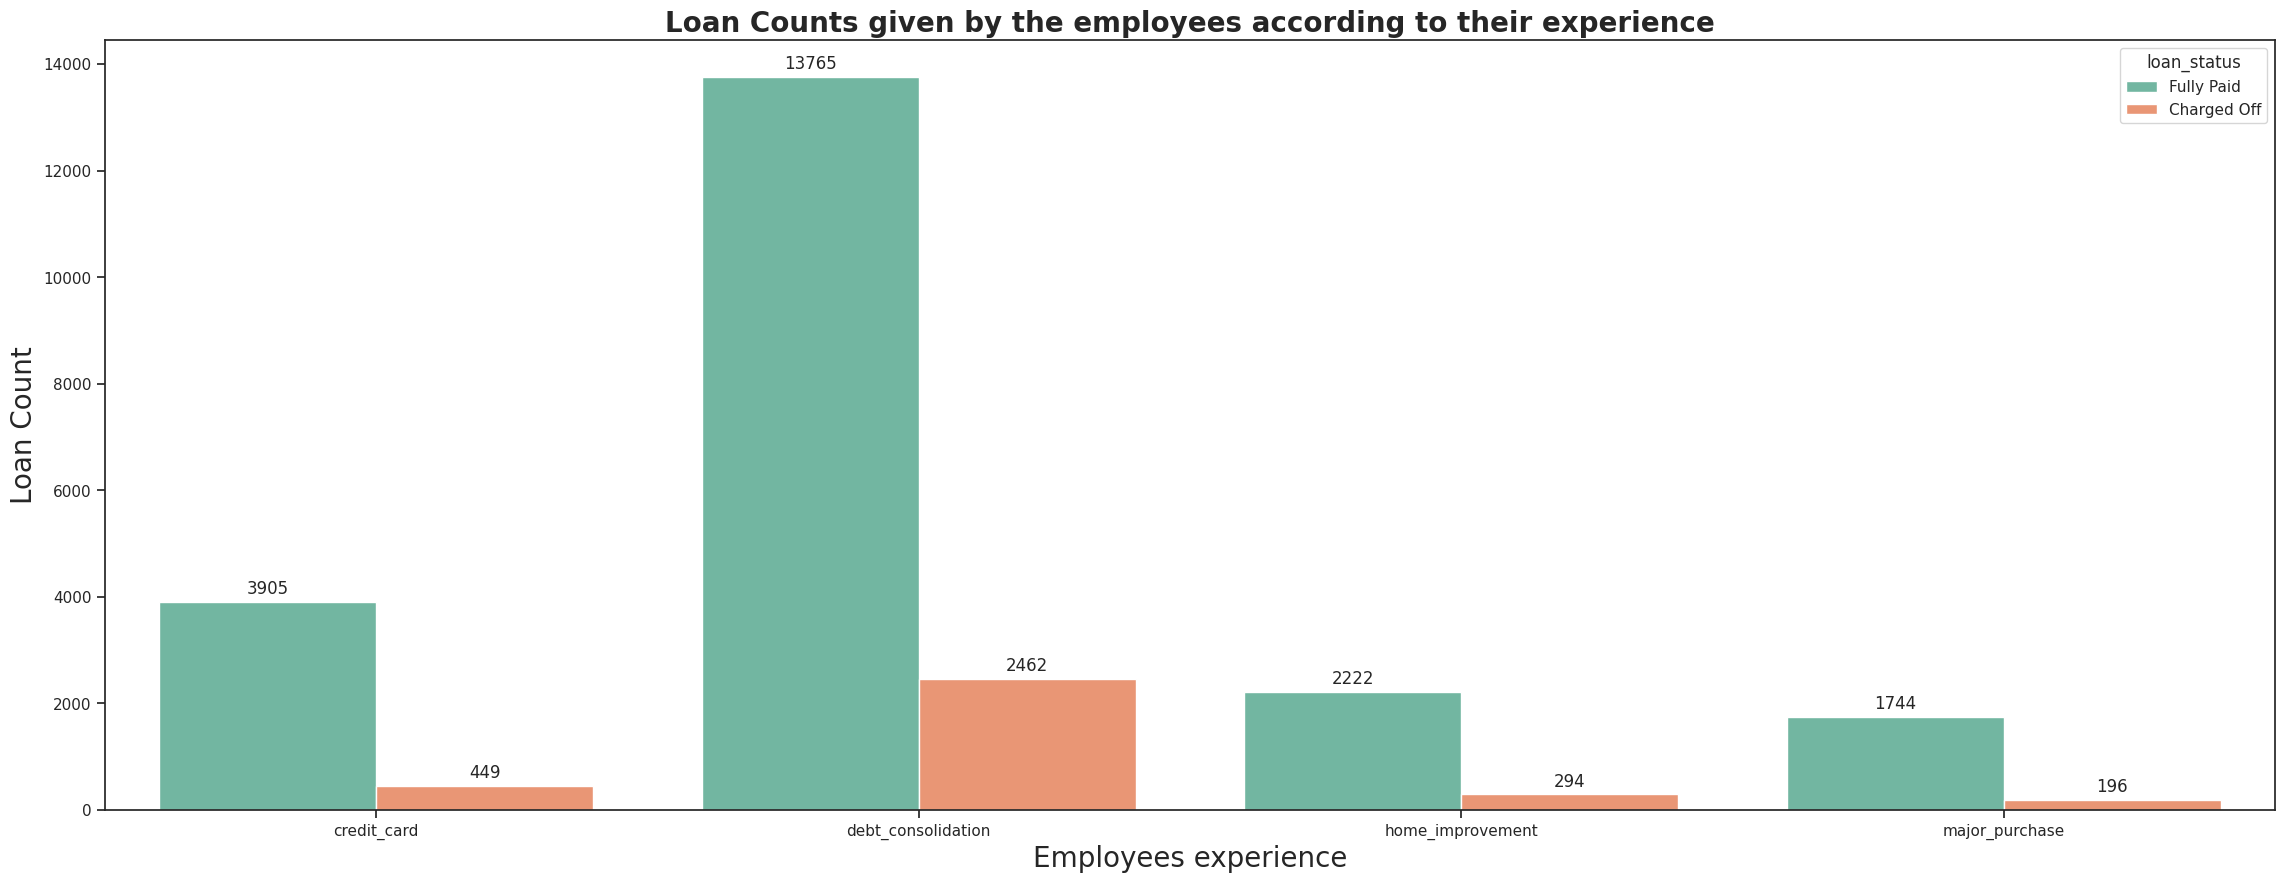

In [233]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 10))

ax = sns.countplot(x= df['purpose'],hue='loan_status', data=df,palette = 'Set2')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


ax.set_title("Loan Counts given by the employees according to their experience",fontsize = 20,weight = 'bold')
ax.set_xlabel("Employees experience" ,fontsize = 20)
ax.set_ylabel("Loan Count",fontsize = 20)

plt.show()

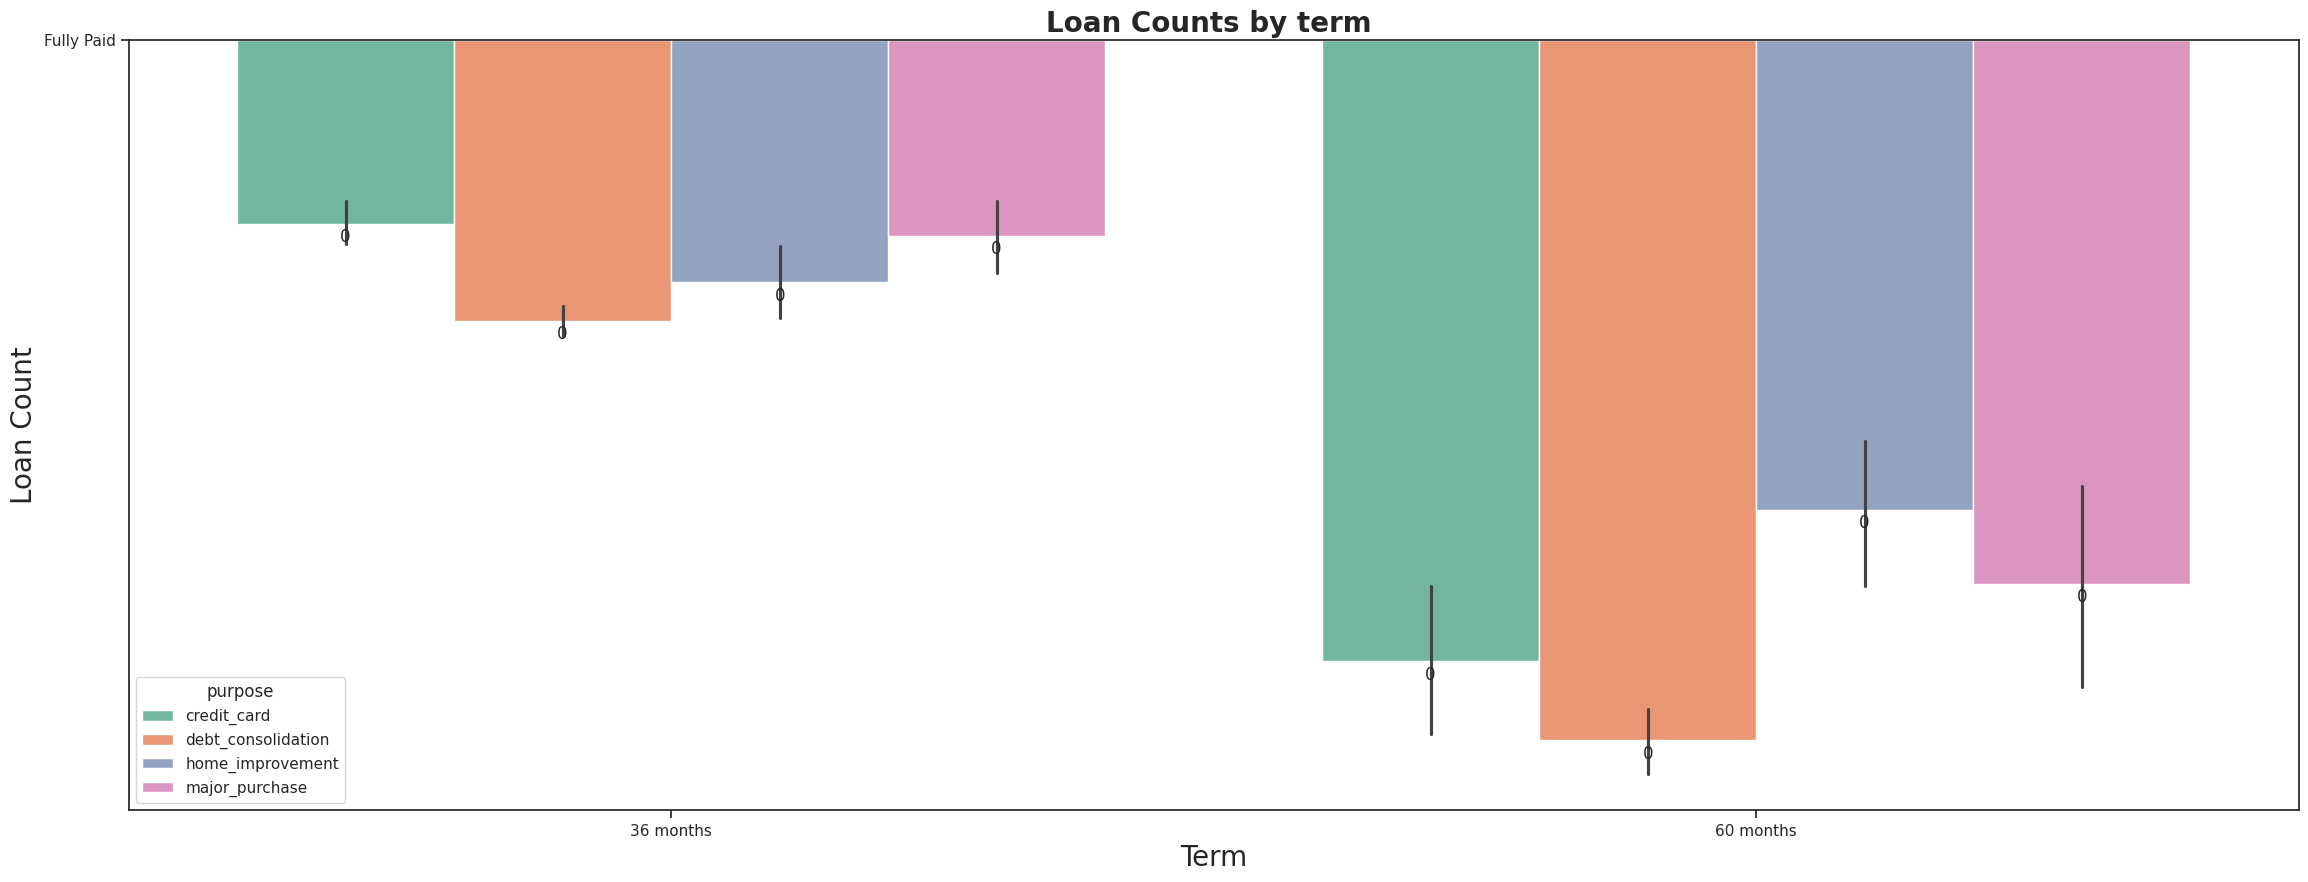

In [234]:
sns.set_theme(style="ticks")
plt.figure(figsize=(28, 10))

ax = sns.barplot(x='term',y = 'loan_status', hue = 'purpose', data=df,palette = 'Set2',orient = 'x')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)


ax.set_title("Loan Counts by term ",fontsize = 20,weight = 'bold')
ax.set_xlabel("Term" ,fontsize = 20)
ax.set_ylabel("Loan Count",fontsize = 20)

plt.show()